   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 35.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


Featurizing molecules into graph topology...


Streaming output truncated to the last 5000 lines.
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:38:52] DEPRECATION WARNING: please use GetValence(Chem.

Splitting data...
Training Graph Convolutional Network...

Evaluation:
Test ROC-AUC: 0.9339
Test F1-Score: 0.8712


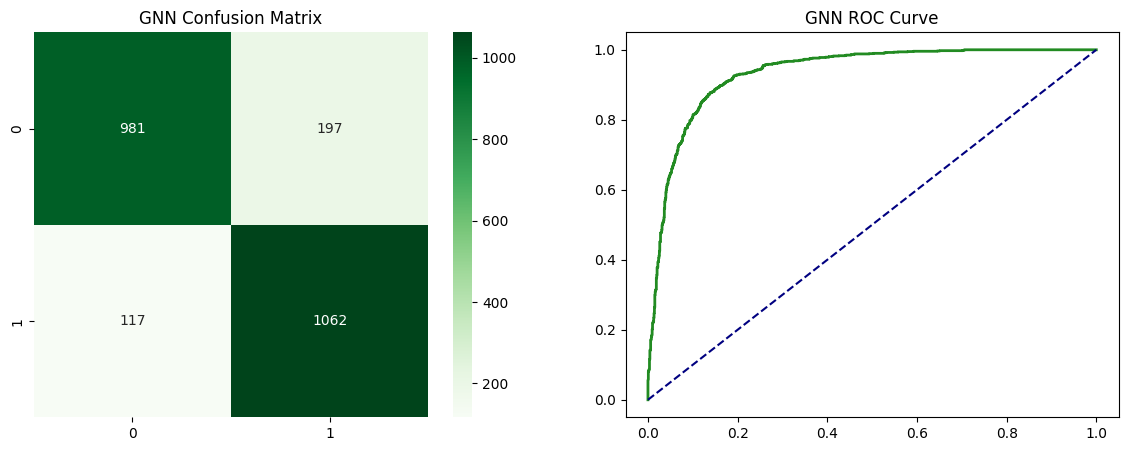

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

!pip install -q deepchem rdkit tf-keras

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import deepchem as dc
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

CACHE_FILE = "/content/cyp19a1_cid_smiles_cache.csv"
df = pd.read_csv(CACHE_FILE).dropna(subset=["SMILES"]).reset_index(drop=True)

potency_col = 'Activity_Value' if 'Activity_Value' in df.columns else df.select_dtypes(include=[np.number]).columns[0]
mid_thresh = df[potency_col].median()
df['target'] = (df[potency_col] <= mid_thresh).astype(int)

print("Featurizing molecules into graph topology...")
featurizer = dc.feat.ConvMolFeaturizer()
X_graphs = featurizer.featurize(df['SMILES'].tolist())
y_targets = df['target'].values.astype(np.float32).reshape(-1, 1)

valid_indices = [i for i, g in enumerate(X_graphs) if g is not None]
X_graphs = [X_graphs[i] for i in valid_indices]
y_targets = y_targets[valid_indices]

dataset = dc.data.NumpyDataset(X=np.array(X_graphs, dtype=object), y=y_targets)

print("Splitting data...")
splitter = dc.splits.RandomStratifiedSplitter()
train_dataset, test_dataset = splitter.train_test_split(dataset, frac_train=0.8, seed=42)

print("Training Graph Convolutional Network...")

gnn_model = dc.models.GraphConvModel(
    n_tasks=1,
    mode='classification',
    learning_rate=0.001,
    model_dir="./gcn_model"
)

gnn_model.fit(train_dataset, nb_epoch=50)

print("\nEvaluation:")
y_test_true = test_dataset.y.flatten()
gnn_probs = gnn_model.predict(test_dataset)[:, 0, 1]
gnn_preds = (gnn_probs >= 0.5).astype(int)

print(f"Test ROC-AUC: {roc_auc_score(y_test_true, gnn_probs):.4f}")
print(f"Test F1-Score: {f1_score(y_test_true, gnn_preds):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test_true, gnn_preds), annot=True, fmt="d", cmap="Greens", ax=ax[0])
ax[0].set_title("GNN Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test_true, gnn_probs)
ax[1].plot(fpr, tpr, color='forestgreen', lw=2)
ax[1].plot([0, 1], [0, 1], linestyle='--', color='navy')
ax[1].set_title("GNN ROC Curve")
plt.show()